In [ ]:
import sys
sys.path.append('../analysis')
from eeg_data import target_filenames

from matplotlib import pyplot as plt

In [ ]:
eeg_dir = '/home/nmuller/projects/fmg_storage/osf_eeg_data/AutoReject'


sub_ids = {}
for sub in range(5, 36):

    filepath = f'/home/nmuller/projects/fmg_storage/OADS EEG Experiment/Subject_matrix/sub_{sub}_randomized_matrix_702.csv'
    with open(filepath, 'r') as f:
        lines = f.readlines()
    sub_ids[sub] = []

    for x in lines:
        if x.strip():
            for y in x.split(','):
                id = y.split('\\')[-1].split('.tiff')[0]
                if f"{id}.tiff" not in target_filenames:
                    sub_ids[sub].append(id)

In [93]:
same_images = np.zeros((len(sub_ids), len(sub_ids)), dtype=int)

In [ ]:
ids_counter = {sub: {} for sub in sub_ids}

for sub in sub_ids:
    for image_id in sub_ids[sub]:
        ids_counter[sub][image_id] = ids_counter[sub].get(image_id, 0) + 1

for comp_sub in range(5, 36):
    for sub in range(5, 36):
        if sub == comp_sub:
            continue

        comb_train_ids = [x for x in ids_counter[comp_sub].keys() if ids_counter[comp_sub][x] == 5]
        comb_test_ids = [x for x in ids_counter[comp_sub].keys() if ids_counter[comp_sub][x] == 10]

        sub_train_ids = [x for x in ids_counter[sub].keys() if ids_counter[sub][x] == 5]
        sub_test_ids = [x for x in ids_counter[sub].keys() if ids_counter[sub][x] == 10]

        if sorted(set(comb_train_ids)) == sorted(set(sub_train_ids)):
            same_images[sub - 5, comp_sub - 5] += 1
        if sorted(set(comb_test_ids)) == sorted(set(sub_test_ids)):
            same_images[sub - 5, comp_sub - 5] += 2

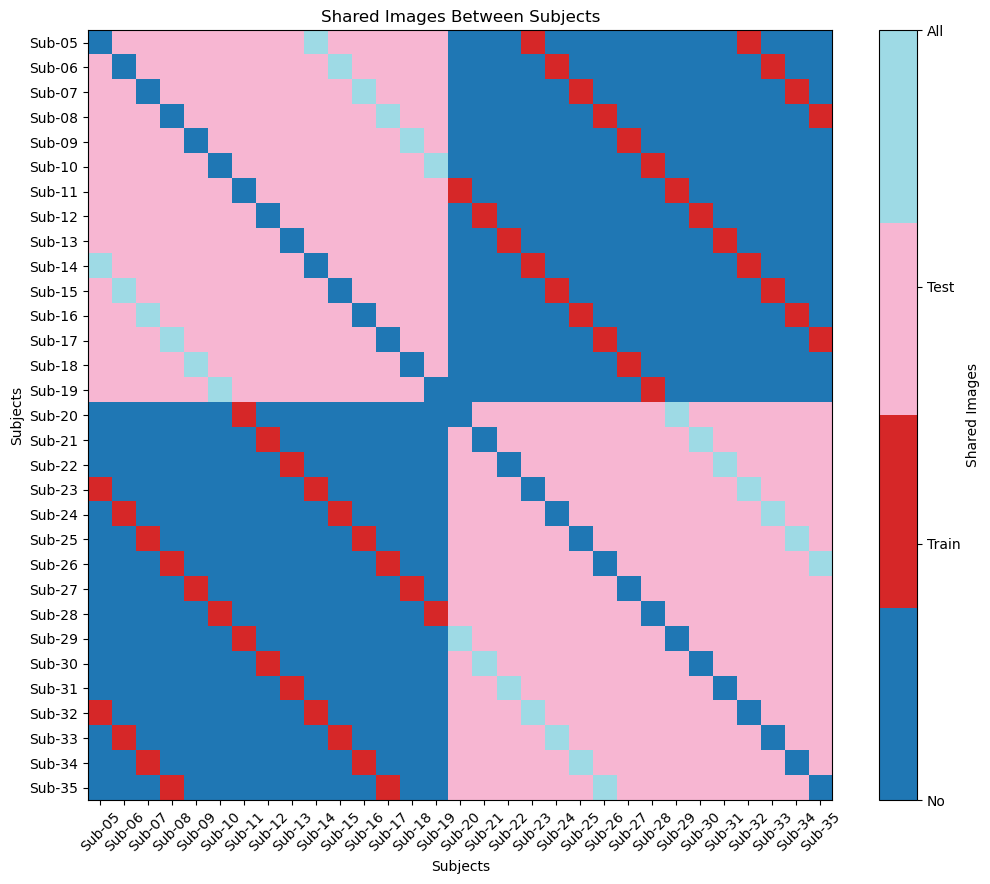

In [102]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
cmap = plt.get_cmap('tab20', 4)
im = ax.imshow(same_images, aspect='auto', cmap=cmap, interpolation='nearest')
cax = plt.colorbar(im, ax=ax, label='Shared Images')
cax.set_ticks([0, 1, 2, 3])
cax.set_ticklabels(['No', 'Train', 'Test', 'All'])
ax.set_xlabel('Subjects')
ax.set_ylabel('Subjects')

ax.set_xticks(range(len(sub_ids)), [f'Sub-{str(i + 5).zfill(2)}' for i in range(len(sub_ids))], rotation=45)
ax.set_yticks(range(len(sub_ids)), [f'Sub-{str(i + 5).zfill(2)}' for i in range(len(sub_ids))])
ax.set_title('Shared Images Between Subjects')

plt.savefig('../figures/images_per_subject.pdf', bbox_inches='tight', dpi=300)
plt.show()